# Customer Churn Prediction & Retention Analytics

In [1]:
# Importing Important Libraries
import numpy as  np 
import pandas as pd 
import seaborn as sns  
import matplotlib.pyplot as plt

# Data Cleaning 
# Filling Null Value 
# EDA(Exploratory Data Analsis

In [2]:
# Load Dataset 
df=pd.read_csv("Telco-Customer-Churn.csv") 


In [3]:
# Top 5 Records 
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Checking Dataset Shape (Rows=7043,Columns=21)
df.shape

(7043, 21)

In [5]:
# Check Columns Name 
df.columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
# Data Information  
df.info()
#(Total_Charges=object Data Type) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# Checking Null Record  
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
# Checking Blank String 
(df==" ").sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
# Check Duplicates 
df.duplicated().sum()

np.int64(0)

In [10]:
# Check Unique Value 
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [11]:
# Convert Total_Charges object to Numeric 
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

In [12]:
# Check Again Null values
df["TotalCharges"].isnull().sum()

np.int64(11)

In [13]:
# FIll Null Values
df["TotalCharges"]=df["TotalCharges"].fillna(df["TotalCharges"].median())

In [14]:
# Remove CustomerID (Because doesn't provide useful predictive information) 
customer_id=df["customerID"] 
df=df.drop("customerID",axis=1)

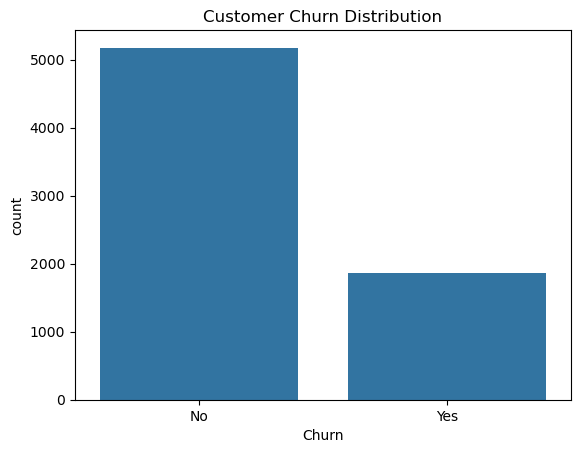

In [15]:
# Churn Distribution 
sns.countplot(x="Churn",data=df) 
plt.title("Customer Churn Distribution") 
plt.show()

In [16]:
# Churn Distribution Percentage 
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

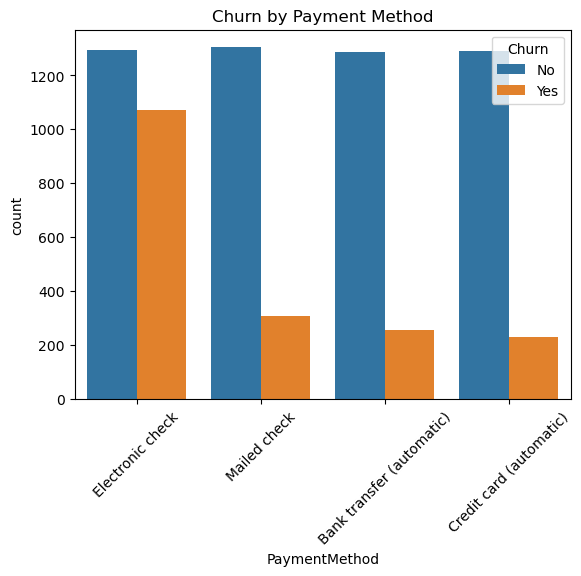

In [17]:
# Churn by payment method 
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

#  Train Test Split and Model Training

In [18]:
# Separating X and y
X=df.drop(["Churn"],axis=1) 
y=df["Churn"]

In [19]:
# Convert Target 
y=y.map({"No":0,"Yes":1})

In [20]:
# Importing ML libraries 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer 

In [21]:
# Split Data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [22]:
# For categorical columns / numnumerical_cols
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

In [23]:
# Preprocessor 
preprocessor=ColumnTransformer(transformers=[
                                        ("num",StandardScaler(),numerical_cols),
                                        ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_cols)])

In [24]:
preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])

# Logistic Model


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [26]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

In [27]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [28]:
y_pred_lr = logistic_model.predict(X_test) # Predict
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1] # Predict Probability

# Decision Tree Model

In [29]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

In [30]:
decision_tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [31]:
y_pred_dt = decision_tree_model.predict(X_test) # Predict 
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1] # predict probability 

 # Random Forest Model 

In [32]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

In [33]:
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [34]:
y_pred_rf = random_forest_model.predict(X_test) # Predict

In [35]:
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1] # Predict Probability

# Gradient Model

In [36]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(random_state=42))
    ]
)

In [37]:
gradient_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model', GradientBoostingClassifier(random_state=42))])

In [38]:
y_pred_gb = gradient_model.predict(X_test)  # predict


In [39]:
y_prob_gb = gradient_model.predict_proba(X_test)[:, 1] # predict Probability

In [40]:
# confusion matrix comparison 
from  sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,roc_auc_score
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],
    "F1": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841874
1,Decision Tree,0.728886,0.489637,0.505348,0.497368,0.657266
2,Random Forest,0.775018,0.597938,0.465241,0.523308,0.818704
3,Gradient Boosting,0.806246,0.673540,0.524064,0.589474,0.843212


In [41]:
# Logistic Cconfusion Matrix Display
import matplotlib.pyplot as plt 
from sklearn.metrics import ConfusionMatrixDisplay

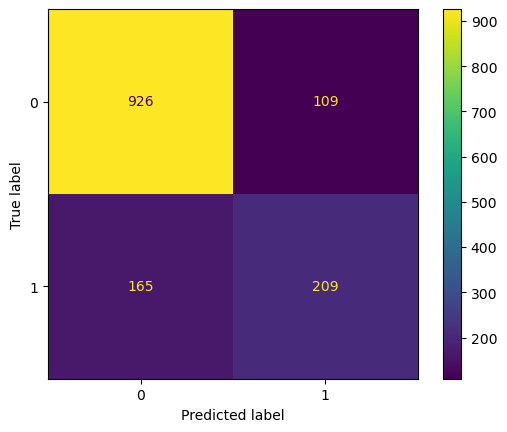

In [42]:
ConfusionMatrixDisplay.from_estimator(logistic_model,X_test,y_test) 
plt.show()

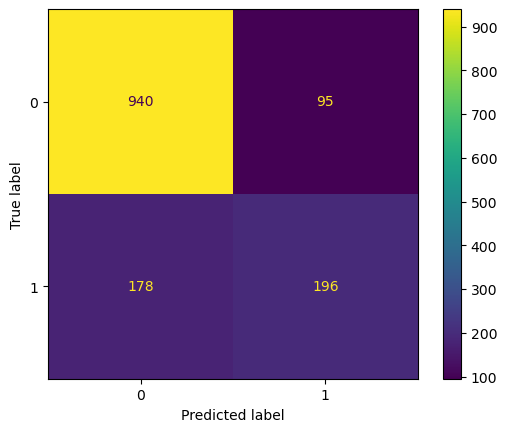

In [43]:
# Gradient Confusion Matrix Display
ConfusionMatrixDisplay.from_estimator(gradient_model,X_test,y_test) 
plt.show()

# Final Conclusion :-


--This project successfully analyzed customer churn behavior for a telecom company using 7,043 customer records.


--We found that churn is not random - it is highly driven by Contract Type, Internet Service, Tenure, and Monthly Charges. Month-to-Month
customers with Fiber Optic and high monthly bills are at the highest risk of churning.Two machine learning models were compared. Gradient Boosting achieved the highest overall accuracy of 80.62%, while Logistic Regression achieved a higher recall of 55.8% for identifying actual churners.
For business purposes, capturing  more churners is more valuable than overall accuracy, hence Logistic Regression is recommended as the final deployable model.

     
--The developed model can help the company proactively identify at-risk customers and reduce churn by 15-20% through targeted retention offers,
thereby increasing revenue and customer loyalty.